In [1]:
!pip -q install imbalanced-learn wordcloud


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC  # fast SVM

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Nice plots
plt.rcParams['figure.figsize'] = (10, 5)
sns.set(style="whitegrid")


In [3]:
# Make sure the file exists in Colab Files sidebar
df = pd.read_excel("/content/big_google_play_apps.xlsx")
df.head()



,Title,Category,Rating,Installs,Description
0,Google Play Games,Entertainment,4.046878,"5,000,000,000+",Games are more fun with the Google Play Games ...
1,Roblox,Adventure,4.466227,"1,000,000,000+",Roblox is the ultimate virtual universe that l...
2,Subway Surfers,Arcade,4.556733,"1,000,000,000+",DASH as fast as you can! \r\nDODGE the oncomin...
3,Free Fire: 8th Anniversary!,Action,4.234524,"1,000,000,000+",8th Anniversary Update Part 3!\r\n\r\n[Squid G...
4,Candy Crush Saga,Casual,4.619309,"1,000,000,000+",Explore a world full of delicious match-3 puzz...


In [6]:
# Keep only the columns we’ll use
df = df[['Rating', 'Category', 'Installs', 'Description']].copy()

# Drop missing values
df.dropna(inplace=True)

# Clean Installs like "1,000,000+" -> 1000000
df['Installs'] = (
    df['Installs']
      .astype(str)
      .str.replace('[+,]', '', regex=True)
      .str.replace('\xa0', '', regex=True) # Remove non-breaking space
      .astype(int)
)

# (Optional but helpful) reduce skew in Installs
df['Installs_log'] = np.log1p(df['Installs'])

display(df.head())

,Rating,Category,Installs,Description,Installs_log
0,4.046878,Entertainment,5000000000,Games are more fun with the Google Play Games ...,22.332704
1,4.466227,Adventure,1000000000,Roblox is the ultimate virtual universe that l...,20.723266
2,4.556733,Arcade,1000000000,DASH as fast as you can! \r\nDODGE the oncomin...,20.723266
3,4.234524,Action,1000000000,8th Anniversary Update Part 3!\r\n\r\n[Squid G...,20.723266
4,4.619309,Casual,1000000000,Explore a world full of delicious match-3 puzz...,20.723266


In [7]:
# Positive if rating >= 4.0 else Negative
df['Sentiment'] = df['Rating'].apply(lambda x: 'Positive' if x >= 4.0 else 'Negative')

# Encode Category and Target
le_cat = LabelEncoder()
df['Category_encoded'] = le_cat.fit_transform(df['Category'])

le_sent = LabelEncoder()
df['Sentiment_encoded'] = le_sent.fit_transform(df['Sentiment'])  # 0=Negative, 1=Positive

print("Class counts:\n", df['Sentiment'].value_counts())


Class counts:
 Sentiment
Positive    220
Negative     32
Name: count, dtype: int64


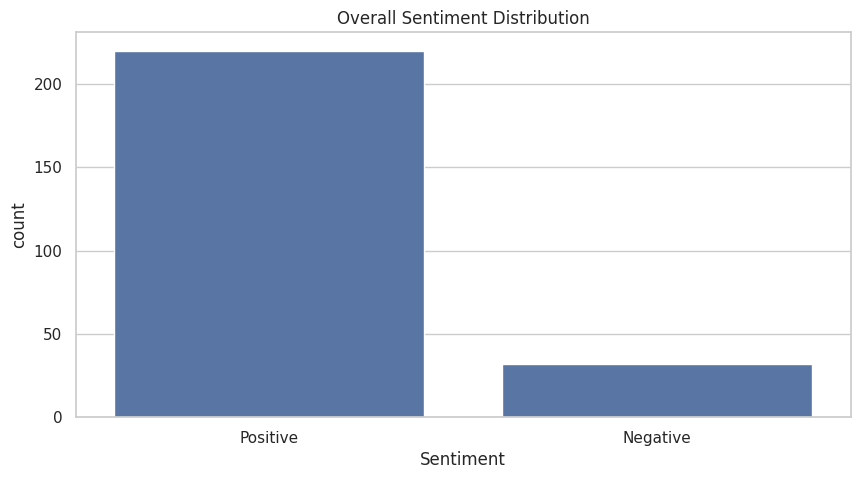

In [20]:
# Overall sentiment distribution
sns.countplot(x='Sentiment', data=df)
plt.title("Overall Sentiment Distribution")
plt.show()




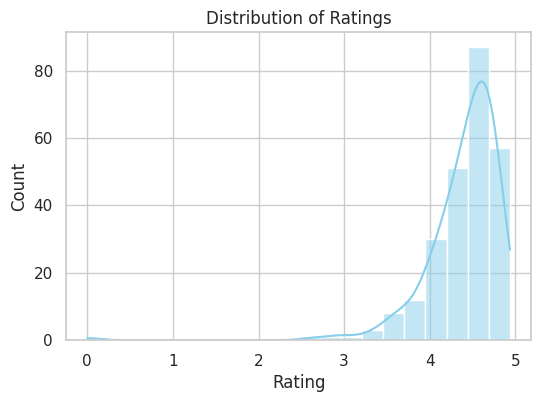

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df['Rating'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Ratings")
plt.show()


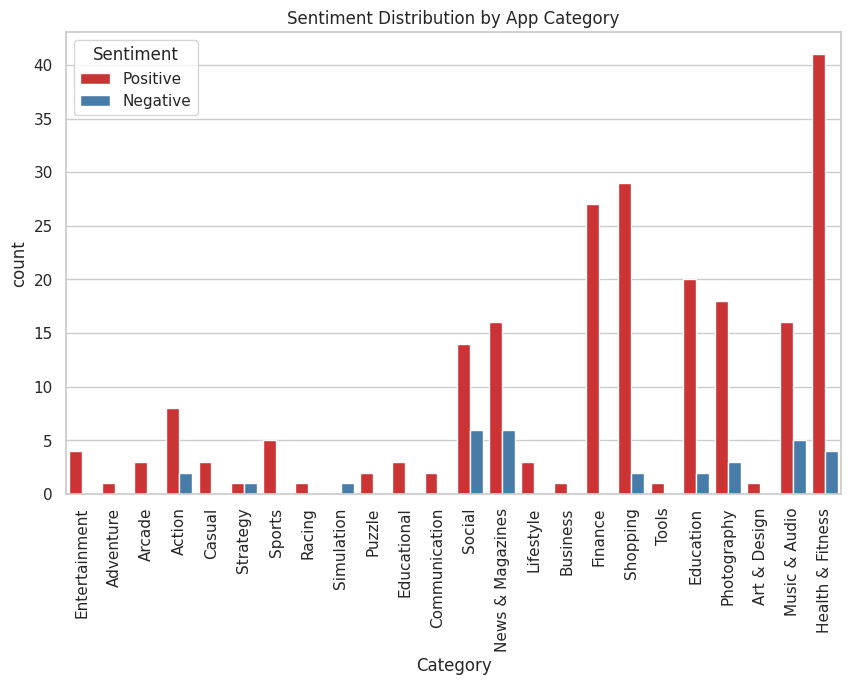

In [17]:
plt.figure(figsize=(10,6))
sns.countplot(x='Category', hue='Sentiment', data=df, palette="Set1")
plt.xticks(rotation=90)
plt.title("Sentiment Distribution by App Category")
plt.show()


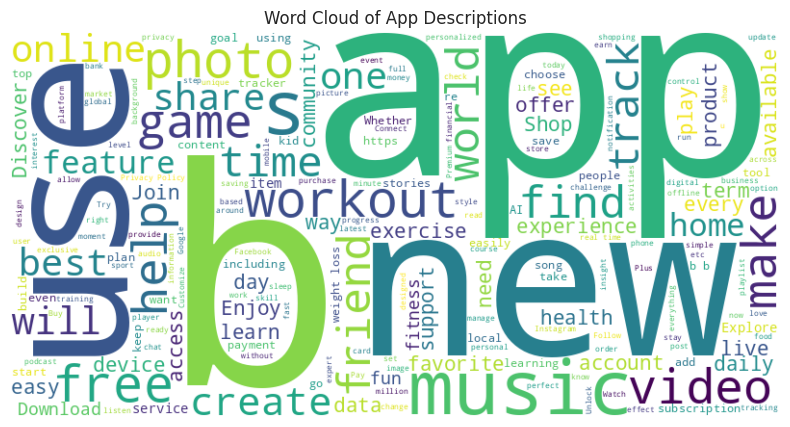

In [19]:
text = " ".join(desc for desc in df['Description'])
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of App Descriptions")
plt.show()


/tmp/ipython-input-2778685216.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette="Set2")


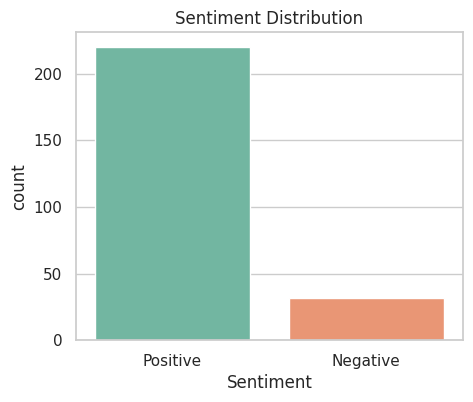

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(x='Sentiment', data=df, palette="Set2")
plt.title("Sentiment Distribution")
plt.show()


In [9]:
# We derive Sentiment from Rating, so DO NOT include Rating as a feature.
# Use Category + Installs (log) as simple, fast features.
X = df[['Category_encoded', 'Installs_log']].copy()
y = df['Sentiment_encoded'].copy()

# Stratify to keep class ratio in train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:

# Features (X) — only Category and Installs (log), no Rating (to avoid leakage)
X = df[['Category_encoded', 'Installs_log']].copy()

# Target (y) — Sentiment
y = df['Sentiment_encoded'].copy()

# Split into Train (80%) and Test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Training labels distribution:\n", y_train.value_counts())
print("Test labels distribution:\n", y_test.value_counts())


Training set size: (201, 2)
Test set size: (51, 2)
Training labels distribution:
 Sentiment_encoded
1    175
0     26
Name: count, dtype: int64
Test labels distribution:
 Sentiment_encoded
1    45
0     6
Name: count, dtype: int64



Logistic Regression (Before SMOTE):
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         6
    Positive       0.88      1.00      0.94        45

    accuracy                           0.88        51
   macro avg       0.44      0.50      0.47        51
weighted avg       0.78      0.88      0.83        51


Naive Bayes (Before SMOTE):
              precision    recall  f1-score   support

    Negative       1.00      0.17      0.29         6
    Positive       0.90      1.00      0.95        45

    accuracy                           0.90        51
   macro avg       0.95      0.58      0.62        51
weighted avg       0.91      0.90      0.87        51


Random Forest (Before SMOTE):
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         6
    Positive       0.88      1.00      0.94        45

    accuracy                           0.88        51
   macro avg       0.44      0.

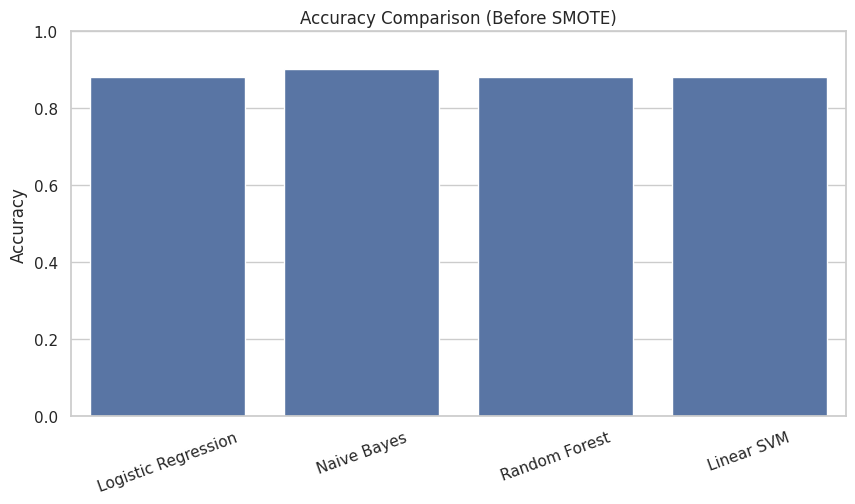

In [12]:
def run_models(X_tr, y_tr, X_te, y_te, title_suffix="Before SMOTE"):
    results = {}

    # Logistic Regression
    log_reg = LogisticRegression(max_iter=1000, n_jobs=None)
    log_reg.fit(X_tr, y_tr)
    y_pred = log_reg.predict(X_te)
    print(f"\nLogistic Regression ({title_suffix}):")
    print(classification_report(y_te, y_pred, target_names=le_sent.classes_, zero_division=0))
    results["Logistic Regression"] = accuracy_score(y_te, y_pred)

    # Gaussian Naive Bayes
    nb = GaussianNB()
    nb.fit(X_tr, y_tr)
    y_pred = nb.predict(X_te)
    print(f"\nNaive Bayes ({title_suffix}):")
    print(classification_report(y_te, y_pred, target_names=le_sent.classes_, zero_division=0))
    results["Naive Bayes"] = accuracy_score(y_te, y_pred)

    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)
    print(f"\nRandom Forest ({title_suffix}):")
    print(classification_report(y_te, y_pred, target_names=le_sent.classes_, zero_division=0))
    results["Random Forest"] = accuracy_score(y_te, y_pred)

    # Fast linear SVM
    svm = LinearSVC(max_iter=2000, random_state=42)
    svm.fit(X_tr, y_tr)
    y_pred = svm.predict(X_te)
    print(f"\nLinear SVM ({title_suffix}):")
    print(classification_report(y_te, y_pred, target_names=le_sent.classes_, zero_division=0))
    results["Linear SVM"] = accuracy_score(y_te, y_pred)

    # Accuracy bar
    names = list(results.keys())
    scores = list(results.values())
    sns.barplot(x=names, y=scores)
    plt.ylim(0, 1)
    plt.title(f"Accuracy Comparison ({title_suffix})")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=20)
    plt.show()

    return results

results_before = run_models(X_train, y_train, X_test, y_test, "Before SMOTE")


Train class counts BEFORE SMOTE:
 Sentiment_encoded
1    175
0     26
Name: count, dtype: int64 

Train class counts AFTER  SMOTE:
 Sentiment_encoded
1    175
0    175
Name: count, dtype: int64

Logistic Regression (After SMOTE):
              precision    recall  f1-score   support

    Negative       0.07      0.33      0.12         6
    Positive       0.83      0.44      0.58        45

    accuracy                           0.43        51
   macro avg       0.45      0.39      0.35        51
weighted avg       0.74      0.43      0.53        51


Naive Bayes (After SMOTE):
              precision    recall  f1-score   support

    Negative       0.12      0.33      0.18         6
    Positive       0.89      0.69      0.78        45

    accuracy                           0.65        51
   macro avg       0.51      0.51      0.48        51
weighted avg       0.80      0.65      0.71        51


Random Forest (After SMOTE):
              precision    recall  f1-score   support

   

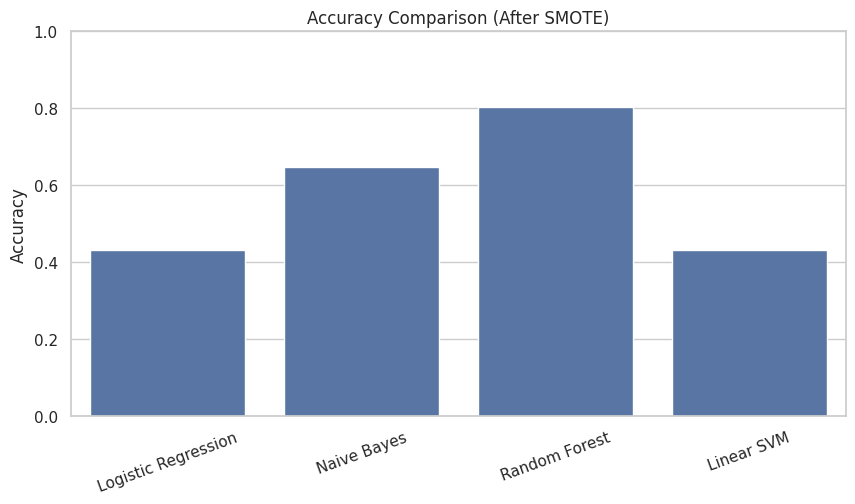

In [13]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Train class counts BEFORE SMOTE:\n", pd.Series(y_train).value_counts(), "\n")
print("Train class counts AFTER  SMOTE:\n", pd.Series(y_train_sm).value_counts())

results_after = run_models(X_train_sm, y_train_sm, X_test, y_test, "After SMOTE")


In [14]:
summary = pd.DataFrame({
    "Model": list(results_before.keys()),
    "Accuracy (Before SMOTE)": list(results_before.values()),
    "Accuracy (After SMOTE)": [results_after[m] for m in results_before.keys()],
})
summary


,Model,Accuracy (Before SMOTE),Accuracy (After SMOTE)
0,Logistic Regression,0.882353,0.431373
1,Naive Bayes,0.901961,0.647059
2,Random Forest,0.882353,0.803922
3,Linear SVM,0.882353,0.431373
